In [22]:
import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [23]:
#imports
import numpy as np
import matplotlib.pyplot as plt

from Data_Pipeline.cleaning import SimpleImputer
from Data_Pipeline.scaling import StandardScaler
from Data_Pipeline.split import train_test_split

In [24]:
#generate realistic data 
def generate_realistic_data(n=1000):
    np.random.seed(42)
    age = np.random.normal(30, 8, n)
    salary = np.random.normal(60000, 15000, n)
    experience = np.random.normal(5, 3, n)
    X = np.column_stack((
        age,
        salary,
        experience
    ))
    score = (
        0.03 * age +
        0.00002 * salary +
        0.5 * experience +
        np.sin(experience)*0.67
    )
    score += np.random.randn(n) * 2
    y = (score > np.median(score)).astype(int)
    return X, y

X_raw, y_raw = generate_realistic_data()
print(X_raw.shape)

(1000, 3)


In [25]:
#missing values 
missing_indices = np.random.choice(
    X_raw.size,
    int(0.05 * X_raw.size),
    replace=False
)
X_raw.flat[missing_indices] = np.nan
print("Missing Values:", np.isnan(X_raw).sum())


#cleaning data 
imputer = SimpleImputer(strategy="mean")
X_clean = imputer.fit_transform(X_raw)
print("Remaining NaNs:", np.isnan(X_clean).sum())

#scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

#split 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_raw,
    test_size=0.2,
    random_state=42
)

Missing Values: 150
Remaining NaNs: 0


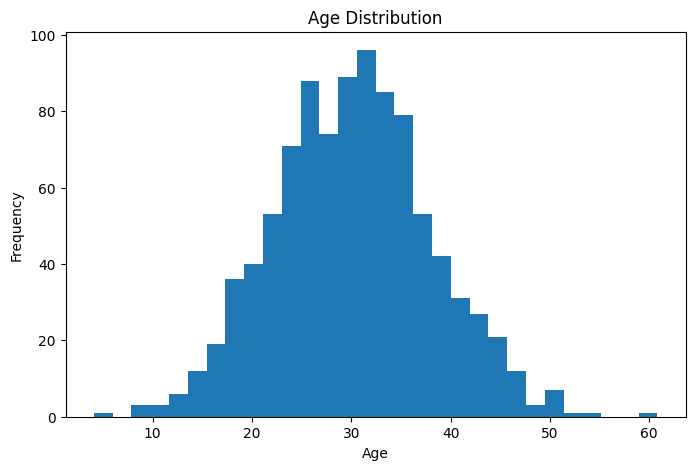

In [26]:
#data visualization
plt.figure(figsize=(8,5))
plt.hist(
    X_raw[:,0][~np.isnan(X_raw[:,0])],
    bins=30
)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [27]:
#NN starts 
input_size = 3
hidden_size = 8
output_size = 1

W1 = np.random.randn(
    input_size,
    hidden_size
) * 0.1

b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(
    hidden_size,
    output_size
) * 0.1

b2 = np.zeros((1, output_size))

In [28]:
#activation functions 
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))



#fwd pass
def forward(X):
    global Z1, A1, Z2, A2
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return A2

#loss function
def compute_loss(y_true, y_pred):
    y_true = y_true.reshape(-1,1)
    epsilon = 1e-8
    loss = -np.mean(
        y_true * np.log(y_pred + epsilon) +
        (1-y_true) * np.log(1-y_pred + epsilon)
    )
    return loss


#back pass 
def backward(X, y, y_pred, lr=0.01):

    global W1, b1, W2, b2
    y = y.reshape(-1,1)
    m = len(X)
    dZ2 = y_pred - y
    dW2 = (A1.T @ dZ2) / m

    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    ) / m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m

    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    ) / m

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

#training 
losses = []
epochs = 1000

for epoch in range(epochs):
    y_pred = forward(X_train)
    loss = compute_loss(
        y_train,
        y_pred
    )
    backward(
        X_train,
        y_train,
        y_pred
    )
    losses.append(loss)
    if epoch % 100 == 0:
        print(
            f"Epoch {epoch} | Loss: {loss:.4f}"
        )

Epoch 0 | Loss: 0.7006
Epoch 100 | Loss: 0.6974
Epoch 200 | Loss: 0.6947
Epoch 300 | Loss: 0.6923
Epoch 400 | Loss: 0.6899
Epoch 500 | Loss: 0.6873
Epoch 600 | Loss: 0.6843
Epoch 700 | Loss: 0.6807
Epoch 800 | Loss: 0.6764
Epoch 900 | Loss: 0.6711


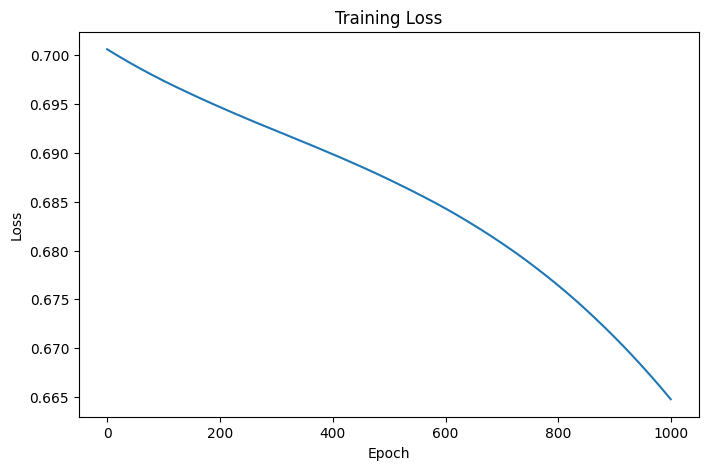

In [29]:
#loss curve 
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [30]:
#prediction
test_probs = forward(X_test)
predictions = (
    test_probs > 0.5
).astype(int)

#accuracy
accuracy = np.mean(
    predictions.flatten() == y_test
)

print("Accuracy:", accuracy)

Accuracy: 0.74


Chaning the number hidden layers increases accuracy, changing the expression helps in understandning more realistic data 